# MATH 70116, Deep Learning
Autumn 2026<br>
Lecturer: Tom Hadfield
## Example: Classification

First we import the relevant libraries and set the plot style.

In [1]:
import numpy as np
import numpy.random as npr
import torch
import matplotlib.pyplot as plt
plt.style.use('ggplot')

Generate an artificial data set $\{ (X_1^i, X_2^i), Y^i \}_{1 \le i \le N}$ as follows:
<ul>
<li> Sample independent and identically distributed realisations $X_1^1,\ldots,X_1^N\sim \mathrm{Uniform}(-1,1)$ and $X_2^1,\ldots,X_2^N\sim \mathrm{Uniform}(-1,1)$ for $N=1\,000\,000$.
<li> Next sample $Y^i \sim \mathrm{Bernoulli}(p_i)$, for any $i = 1,\ldots,N$,
where
$p_i :=  p(X^i_1,X^i_2)$
is defined using
$$
p(x_1,x_2) := \mathrm{Sigmoid}\bigg(3\sin\Big(10\sqrt{x_1^2+x_2^2}\Big)\bigg), \quad (x_1,x_2) \in \mathbb{R}^2.
$$
</ul>
We now "forget" about $p$ and consider $(X^1,Y^1),\ldots,(X^N,Y^N)$ as our training data (here we denote $X^i = (X_1^i, X_2^i))$. 
Our aim is to train a binary classifier that, given coordinates $(x_1,x_2)$, predicts whether the associated label will be $0$ or $1$. For this, we use a deep neural network $\hat{p} \colon \mathbb{R}^2 \to [0,1]$ to approximate the conditional probability $\mathbb{P}(Y^i = 1 | (X^i_1,X^i_2)=(x_1,x_2)) = p(x_1,x_2)$.  In other words, our neural network will learn $p$ from the labels $Y^1,\ldots,Y^N$.

We first define the functions $\mathrm{Sigmoid}$ and $p$.

In [2]:
def sigmoid(x):
    return 1 / (1+np.exp(-x))

def this_heaviside(x):
    if x > 0.0:
        return 1.0
    else:
        return 0.0

# Apply the function using np.vectorize
this_vec_heaviside = np.vectorize(this_heaviside)
 
def pfunc_test(x_1, x_2):
    return this_vec_heaviside(x_1 + x_2)

def pfunc(x_1, x_2):
    return sigmoid(3 * np.sin(10 * np.sqrt(x_1**2 + x_2**2)))

Generate some sample data.

In [3]:
N = 100000 #1000000
X_1 = npr.uniform(-1, 1, N)
X_2 = npr.uniform(-1, 1, N) 
Y = npr.binomial(1, pfunc(X_1, X_2), (N,))
X_1 = np.reshape(X_1, (N, 1))
X_2 = np.reshape(X_2, (N, 1))
X = np.concatenate((X_1,X_2),1)
Y = np.reshape(Y, (N,1))

In [4]:
print(X.shape)
print(Y.shape)

(100000, 2)
(100000, 1)


Plot the first $4000$ samples.

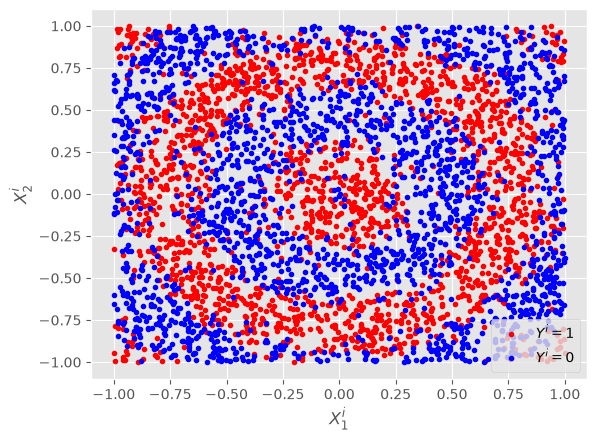

In [5]:
Nsub = 4000
plt.plot(X_1[0:(Nsub-1)][Y[0:(Nsub-1)]==1], 
         X_2[0:(Nsub-1)][Y[0:(Nsub-1)]==1], 
         "ro", markersize=3, label = "$Y^i = 1$")
plt.plot(X_1[0:(Nsub-1)][Y[0:(Nsub-1)]==0], 
         X_2[0:(Nsub-1)][Y[0:(Nsub-1)]==0], 
         "bo", markersize=3, label = "$Y^i = 0$")
plt.xlabel(r"$X^i_1$")
plt.ylabel(r"$X^i_2$")
plt.legend()
plt.show()

Let us try to train a network $\widehat{p} \in \mathcal{N}_4(2,n,n,n,1;\mathrm{ELU},\mathrm{ELU},\mathrm{ELU},\sigma)$ for different choices $n \in \{5,20,200\}$.

ELU (Exponential Linear Unit) is the activation function defined by:
$ELU (x) = x, x \ge 0$, 
$ELU(x) = \alpha (e^x  - 1), x \le 0$
where $\alpha$ is a parameter
if we take $\alpha = 1$, then ELU is has continuous first derivative at $x = 0$

In [6]:
import torch.nn as nn

n = 100

f = nn.Sequential(
    nn.Linear(2, n),
    nn.ELU(),
    nn.Linear(n, n),
    nn.ELU(),
    nn.Linear(n, n),
    nn.ELU(),
    nn.Linear(n, 1),
	nn.Sigmoid()
)

In [7]:
print(f)

Sequential(
  (0): Linear(in_features=2, out_features=100, bias=True)
  (1): ELU(alpha=1.0)
  (2): Linear(in_features=100, out_features=100, bias=True)
  (3): ELU(alpha=1.0)
  (4): Linear(in_features=100, out_features=100, bias=True)
  (5): ELU(alpha=1.0)
  (6): Linear(in_features=100, out_features=1, bias=True)
  (7): Sigmoid()
)


Compile and train $\widehat{p}$ with $Y$ and $\boldsymbol{X}$ using binary cross-entropy loss and Adam optimisation algorithm. We will do $5$ epochs with minibatch size $500$. We monitor the metric <b>accuracy</b>, defined as
\begin{equation*}
\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}.
\end{equation*}

In [8]:
eta = 0.01
optimizer = torch.optim.Adam(f.parameters(), lr=eta)
loss_fn = nn.BCELoss()

In [9]:
def accuracy(y_pred, y_true, threshold=0.5):
    preds = (y_pred >= threshold).float()
    return (preds == y_true).float().mean().item()

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

def train_model(
    model,
    X,
    y,
    loss_fn,
    optimizer,
    epochs=100,
    batch_size=32,
    metrics=None,
    X_val=None,
    y_val=None,
    validation_split=0.0,   
    verbose_every=10,
    device=None,
):
    """
    Generic training loop for a PyTorch model.

    ... (same as before) ...

    validation_split : float in [0.0, 1.0)
        Fraction of (X, y) to hold out as validation data, taken from the
        END of the dataset (matching Keras's default behavior). Ignored if
        X_val and y_val are both explicitly provided.
    """
    if not (0.0 <= validation_split < 1.0):
        raise ValueError("validation_split must be in [0.0, 1.0)")

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    def to_tensor(a):
        if isinstance(a, np.ndarray):
            return torch.from_numpy(a).float()
        return a.float()

    X = to_tensor(X)
    y = to_tensor(y)

    # --- Handle validation_split (only if X_val/y_val not already given) ---
    if X_val is None and y_val is None and validation_split > 0.0:
        n_total = X.shape[0]
        n_val = int(round(n_total * validation_split))
        n_train = n_total - n_val

        X_val = X[n_train:]
        y_val = y[n_train:]
        X = X[:n_train]
        y = y[:n_train]
        print("n_total = ", n_total, "n_val = ", n_val, "n_train = ", n_train)

    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    has_val = X_val is not None and y_val is not None
    if has_val:
        X_val = to_tensor(X_val).to(device)
        y_val = to_tensor(y_val).to(device)

    metrics = metrics or {}

    history = {"loss": []}
    history.update({name: [] for name in metrics})
    if has_val:
        history["val_loss"] = []
        history.update({f"val_{name}": [] for name in metrics})

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_metrics = {name: 0.0 for name in metrics}
        n_samples = 0

        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            bs = X_batch.size(0)
            running_loss += loss.item() * bs
            for name, fn in metrics.items():
                running_metrics[name] += fn(y_pred, y_batch) * bs
            n_samples += bs

        epoch_loss = running_loss / n_samples
        print("epoch = ", epoch, ", loss = ", epoch_loss) 
        history["loss"].append(epoch_loss)
        for name in metrics:
            val = running_metrics[name] / n_samples
            history[name].append(val)

        log_str = f"Epoch {epoch+1}/{epochs}, loss: {epoch_loss:.4f}"
        for name in metrics:
            log_str += f", {name}: {history[name][-1]:.4f}"

        if has_val:
            model.eval()
            with torch.no_grad():
                y_val_pred = model(X_val)
                val_loss = loss_fn(y_val_pred, y_val).item()
                history["val_loss"].append(val_loss)
                print("epoch = ", epoch, ", val_loss = ", val_loss) 
                log_str += f", val_loss: {val_loss:.4f}"
                for name, fn in metrics.items():
                    val_metric = fn(y_val_pred, y_val)
                    history[f"val_{name}"].append(val_metric)
                    log_str += f", val_{name}: {val_metric:.4f}"

        if verbose_every and (epoch + 1) % verbose_every == 0:
            print(log_str)

    return history

In [11]:
print(Y.mean())
print(Y.dtype, Y.shape)

0.49595
int32 (100000, 1)


In [12]:
num_epochs = 20

train = train_model(
    f,
    X,
    Y,
    loss_fn,
    optimizer,
    epochs=num_epochs,
    batch_size=100,
    validation_split = 0.2)

n_total =  100000 n_val =  20000 n_train =  80000
epoch =  0 , loss =  0.6923133052140474
epoch =  0 , val_loss =  0.6807126998901367
epoch =  1 , loss =  0.6726371355354785
epoch =  1 , val_loss =  0.621013879776001
epoch =  2 , loss =  0.5321124389767646
epoch =  2 , val_loss =  0.4565235674381256
epoch =  3 , loss =  0.43989572022110224
epoch =  3 , val_loss =  0.46670520305633545
epoch =  4 , loss =  0.42882762355729936
epoch =  4 , val_loss =  0.43357089161872864
epoch =  5 , loss =  0.42806728653609755
epoch =  5 , val_loss =  0.4263244867324829
epoch =  6 , loss =  0.42337492313235997
epoch =  6 , val_loss =  0.41352319717407227
epoch =  7 , loss =  0.4212957689538598
epoch =  7 , val_loss =  0.4368149936199188
epoch =  8 , loss =  0.4244306690245867
epoch =  8 , val_loss =  0.47017040848731995
epoch =  9 , loss =  0.42330895859748124
epoch =  9 , val_loss =  0.42017117142677307
Epoch 10/20, loss: 0.4233, val_loss: 0.4202
epoch =  10 , loss =  0.4193755827099085
epoch =  10 , va

In [13]:
print(train)

{'loss': [0.6923133052140474, 0.6726371355354785, 0.5321124389767646, 0.43989572022110224, 0.42882762355729936, 0.42806728653609755, 0.42337492313235997, 0.4212957689538598, 0.4244306690245867, 0.42330895859748124, 0.4193755827099085, 0.42165186677128075, 0.41790532870218156, 0.42019135657697915, 0.42026435600593687, 0.42287628520280124, 0.42132593113929034, 0.4189786107465625, 0.4183542872592807, 0.4200271556898951], 'val_loss': [0.6807126998901367, 0.621013879776001, 0.4565235674381256, 0.46670520305633545, 0.43357089161872864, 0.4263244867324829, 0.41352319717407227, 0.4368149936199188, 0.47017040848731995, 0.42017117142677307, 0.41900214552879333, 0.46477010846138, 0.4174932539463043, 0.41597917675971985, 0.42740681767463684, 0.41103845834732056, 0.43277761340141296, 0.427916556596756, 0.4092761278152466, 0.4191998541355133]}


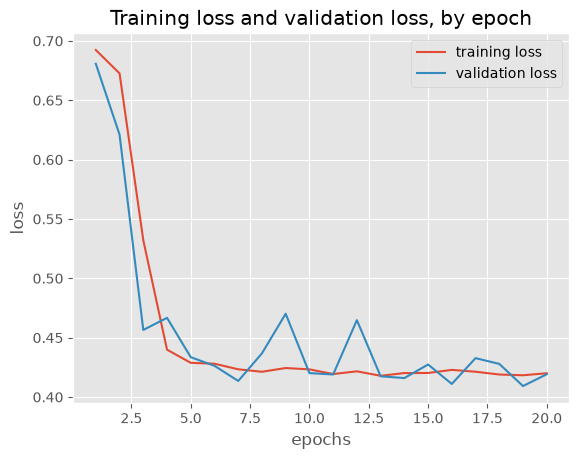

In [14]:
training_loss_vals = train['loss']
validation_loss_vals = train['val_loss']
epoch_num_vals = np.arange(1,len(training_loss_vals) + 1)

this_title = "Training loss and validation loss, by epoch"

plt.plot(epoch_num_vals, training_loss_vals, label="training loss")
plt.plot(epoch_num_vals, validation_loss_vals, label = "validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title(this_title)
plt.legend()
plt.show()

After training, plot the true function $p$ first.

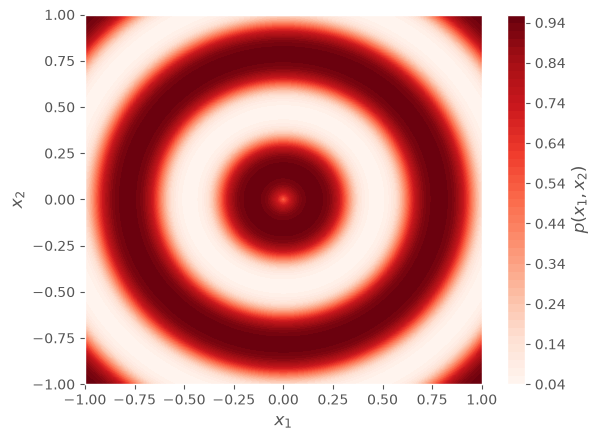

In [15]:
grid = np.linspace(-1, 1, num=1001)
X_1g, X_2g = np.meshgrid(grid, grid)
ptrue = pfunc(X_1g, X_2g)
plt.contourf(X_1g, X_2g, ptrue, 50, cmap="Reds")
cbar = plt.colorbar()
cbar.ax.set_ylabel(r"$p(x_1,x_2)$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.show()

Now plot the trained $\widehat{p}$.

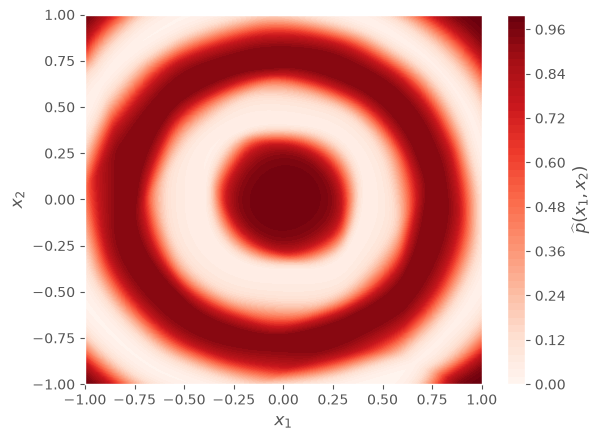

In [16]:
X_1gf = np.reshape(X_1g, (1001*1001, 1))
X_2gf = np.reshape(X_2g, (1001*1001, 1))
Xf = np.concatenate((X_1gf, X_2gf), 1)

# get the device the model is currently on
device = next(f.parameters()).device  

# 1. Make sure Xft is a float32 tensor
if isinstance(Xf, np.ndarray):
    Xft = torch.from_numpy(Xf).float()
else:
    Xft = Xf.float()

# 2. Make sure it's on the same device as the model
device = next(f.parameters()).device
Xft = Xft.to(device)

# 3. Set eval mode and disable gradient tracking for inference
f.eval()
with torch.no_grad():
    ppred = f(Xft)

ppred_np = ppred.cpu().numpy()
ppred_np = np.reshape(ppred_np,(1001, 1001))

plt.contourf(X_1g, X_2g, ppred_np, 50, cmap="Reds")
cbar = plt.colorbar()
cbar.ax.set_ylabel(r"$\widehat{p}(x_1,x_2)$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.show()

Assess the error $|\widehat{p}-p|$

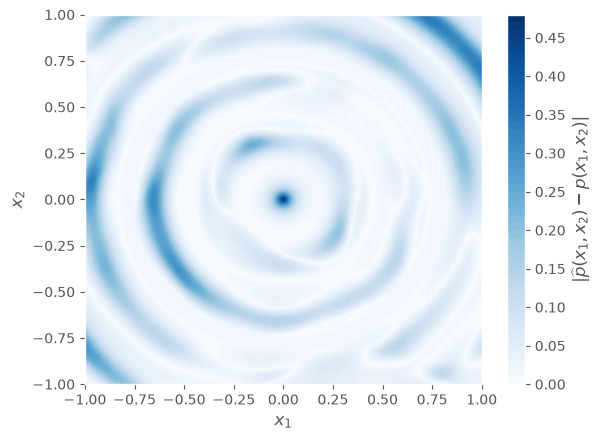

In [17]:
plt.contourf(X_1g, X_2g, np.abs(ptrue-ppred_np), 50, cmap="Blues")
cbar = plt.colorbar()
cbar.ax.set_ylabel(r"$|\widehat{p}(x_1,x_2)-p(x_1,x_2)|$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.show()

# Exercises:

In the definition of the network, try $n = 5, 20, 200$

Try more / fewer layers

Adjust the learning rate

What do you observe?